# OdiaGPT — Visualization Dashboard (FINAL FIXED)
**Root cause of previous error:** Visualization notebook used shortened variable names.  
Checkpoint keys proved the exact names needed:  
`block_list` · `multihead_attention` · `feed_forward` · `layer_1/layer_2` · `addnorm_1/2/3` · `layer_norm` · `projection_layer`

**Run order:** STEP 1 → 2 → 3 → 4 → 5 → then any VIZ cell

## STEP 1: Memory + Imports

In [1]:
import os, gc, math, random
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import sacrebleu
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tqdm import tqdm

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("✅ Ready.")

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB
✅ Ready.


## STEP 2: Load Dataset + Tokenizers

In [2]:
print("Loading Samanantar dataset...")
raw_dataset = load_dataset("ai4bharat/samanantar", "or", split="train")
TRAIN_SIZE, VAL_SIZE = 500000, 3000
raw_train_dataset, rest = random_split(raw_dataset, [TRAIN_SIZE, len(raw_dataset)-TRAIN_SIZE])
raw_val_dataset, _      = random_split(rest, [VAL_SIZE, len(rest)-VAL_SIZE])
print(f"Train: {len(raw_train_dataset):,}  Val: {len(raw_val_dataset):,}")

tokenizer_en = Tokenizer.from_file("./tokenizer_en/tokenizer_en.json")
tokenizer_or = Tokenizer.from_file("./tokenizer_or/tokenizer_or.json")
print(f"EN vocab: {tokenizer_en.get_vocab_size()}  OR vocab: {tokenizer_or.get_vocab_size()}")

max_seq_len = 160
gc.collect()
print("✅ Done.")

Loading Samanantar dataset...
Train: 500,000  Val: 3,000
EN vocab: 30000  OR vocab: 30000
✅ Done.


## STEP 3: Model Architecture
**Every class name, attribute name, and layer name here is IDENTICAL to OdiaGPT_500k_Clean.ipynb.**  
This is verified from the checkpoint key names in the error log.

In [3]:
# ══════════════════════════════════════════════════════════════
# ARCHITECTURE — VERIFIED FROM CHECKPOINT KEYS
# Keys confirmed: block_list, multihead_attention, feed_forward,
#                 layer_1, layer_2, addnorm_1/2/3, layer_norm,
#                 projection_layer
# ══════════════════════════════════════════════════════════════

def causal_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal=1).type(torch.int)
    return mask == 0

class EmbeddingLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_seq_len: int, dropout_rate: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        pe  = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.shape[1], :].requires_grad_(False))

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout_rate: float):
        super().__init__()
        assert d_model % num_heads == 0
        self.dropout   = nn.Dropout(dropout_rate)
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    def forward(self, q, k, v, mask):
        B     = q.shape[0]
        query = self.W_q(q).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        key   = self.W_k(k).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        value = self.W_v(v).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = (query @ key.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        scores = self.dropout(scores.softmax(dim=-1))
        out = (scores @ value).transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.d_k)
        return self.W_o(out)

class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout_rate: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.layer_1 = nn.Linear(d_model, d_ff)   # ← must be layer_1
        self.layer_2 = nn.Linear(d_ff, d_model)   # ← must be layer_2
    def forward(self, x):
        return self.layer_2(self.dropout(torch.relu(self.layer_1(x))))

class LayerNorm(nn.Module):
    def __init__(self, d_model: int = 512, eps: float = 1e-5):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

class AddAndNorm(nn.Module):
    def __init__(self, d_model: int, dropout_rate: float):
        super().__init__()
        self.dropout    = nn.Dropout(dropout_rate)
        self.layer_norm = LayerNorm(d_model)       # ← must be layer_norm
    def forward(self, x, sub_layer):
        return x + self.dropout(sub_layer(self.layer_norm(x)))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, multihead_attention, feed_forward, dropout_rate):
        super().__init__()
        self.multihead_attention = multihead_attention  # ← must be multihead_attention
        self.feed_forward        = feed_forward          # ← must be feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, mask):
        x = self.addnorm_1(x, lambda x: self.multihead_attention(x, x, x, mask))
        x = self.addnorm_2(x, self.feed_forward)
        return x

class Encoder(nn.Module):
    def __init__(self, d_model, block_list: nn.ModuleList):
        super().__init__()
        self.block_list = block_list          # ← must be block_list
        self.layer_norm = LayerNorm(d_model)  # ← must be layer_norm
    def forward(self, x, mask):
        for block in self.block_list:
            x = block(x, mask)
        return self.layer_norm(x)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, masked_attn, cross_attn, feed_forward, dropout_rate):
        super().__init__()
        self.masked_attn  = masked_attn   # ← must be masked_attn
        self.cross_attn   = cross_attn    # ← must be cross_attn
        self.feed_forward = feed_forward  # ← must be feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_3 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, enc_out, enc_mask, dec_mask):
        x = self.addnorm_1(x, lambda x: self.masked_attn(x, x, x, dec_mask))
        x = self.addnorm_2(x, lambda x: self.cross_attn(x, enc_out, enc_out, enc_mask))
        x = self.addnorm_3(x, self.feed_forward)
        return x

class Decoder(nn.Module):
    def __init__(self, d_model, block_list: nn.ModuleList):
        super().__init__()
        self.block_list = block_list          # ← must be block_list
        self.layer_norm = LayerNorm(d_model)  # ← must be layer_norm
    def forward(self, x, enc_out, enc_mask, dec_mask):
        for block in self.block_list:
            x = block(x, enc_out, enc_mask, dec_mask)
        return self.layer_norm(x)

class ProjectionLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)
    def forward(self, x):
        return self.proj(x)

class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed,
                 src_pos, tgt_pos, projection_layer):
        super().__init__()
        self.encoder          = encoder
        self.decoder          = decoder
        self.src_embed        = src_embed
        self.tgt_embed        = tgt_embed
        self.src_pos          = src_pos
        self.tgt_pos          = tgt_pos
        self.projection_layer = projection_layer  # ← must be projection_layer
    def encode(self, src, src_mask):
        return self.encoder(self.src_pos(self.src_embed(src)), src_mask)
    def decode(self, enc_out, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_pos(self.tgt_embed(tgt)), enc_out, src_mask, tgt_mask)
    def project(self, x):
        return self.projection_layer(x)

def build_model(src_vocab, tgt_vocab, seq_len,
                d_model=512, num_blocks=6, num_heads=8, dropout_rate=0.1, d_ff=2048):
    src_embed = EmbeddingLayer(d_model, src_vocab)
    tgt_embed = EmbeddingLayer(d_model, tgt_vocab)
    src_pos   = PositionalEncoding(d_model, seq_len, dropout_rate)
    tgt_pos   = PositionalEncoding(d_model, seq_len, dropout_rate)
    encoder_blocks = [
        EncoderBlock(d_model,
                     MultiHeadAttention(d_model, num_heads, dropout_rate),
                     FeedForward(d_model, d_ff, dropout_rate),
                     dropout_rate)
        for _ in range(num_blocks)
    ]
    decoder_blocks = [
        DecoderBlock(d_model,
                     MultiHeadAttention(d_model, num_heads, dropout_rate),
                     MultiHeadAttention(d_model, num_heads, dropout_rate),
                     FeedForward(d_model, d_ff, dropout_rate),
                     dropout_rate)
        for _ in range(num_blocks)
    ]
    model = Transformer(
        Encoder(d_model, nn.ModuleList(encoder_blocks)),
        Decoder(d_model, nn.ModuleList(decoder_blocks)),
        src_embed, tgt_embed, src_pos, tgt_pos,
        ProjectionLayer(d_model, tgt_vocab)
    )
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

model = build_model(
    tokenizer_en.get_vocab_size(),
    tokenizer_or.get_vocab_size(),
    max_seq_len
).to(device)
print(f"✅ Model built: {sum(p.numel() for p in model.parameters()):,} parameters")

✅ Model built: 90,213,680 parameters


## STEP 4: Load Checkpoint + Beam Search

In [4]:
def load_epoch(epoch):
    ckpt = torch.load(f"./odiagpt/model_{epoch}.pt",
                      map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"✅ Loaded model_{epoch}.pt")

def clean_odia(text):
    for t in ["[CLS]","[SEP]","[PAD]","[UNK]","[MASK]","Name","I / O","unit","format","_u"]:
        text = text.replace(t, "")
    while "  " in text:
        text = text.replace("  ", " ")
    return text.strip()

def odiagpt_beam(text, beam_size=3, max_len=None):
    if max_len is None:
        max_len = max_seq_len
    model.eval()
    with torch.no_grad():
        CLS_EN = tokenizer_en.token_to_id("[CLS]")
        SEP_EN = tokenizer_en.token_to_id("[SEP]")
        PAD_EN = tokenizer_en.token_to_id("[PAD]")
        src = [CLS_EN] + tokenizer_en.encode(text).ids[:max_len-2] + [SEP_EN]
        src += [PAD_EN] * (max_len - len(src))
        src      = torch.tensor(src, dtype=torch.int64).unsqueeze(0).to(device)
        src_mask = (src != PAD_EN).unsqueeze(1).unsqueeze(2).int()
        enc_out  = model.encode(src, src_mask)
        CLS = tokenizer_or.token_to_id("[CLS]")
        SEP = tokenizer_or.token_to_id("[SEP]")
        PAD = tokenizer_or.token_to_id("[PAD]")
        beams, completed = [(torch.tensor([[CLS]], device=device), 0.0)], []
        for _ in range(max_len):
            new_beams = []
            for seq, score in beams:
                if seq[0,-1].item() == SEP:
                    completed.append((seq, score)); continue
                dm  = causal_mask(seq.size(1)).to(device)
                out = model.decode(enc_out, src_mask, seq, dm)
                lp  = torch.log_softmax(model.project(out[:,-1]), dim=-1)
                tp, ti = torch.topk(lp, beam_size)
                for i in range(beam_size):
                    new_beams.append((
                        torch.cat([seq, torch.tensor([[ti[0,i].item()]], device=device)], dim=1),
                        score + tp[0,i].item()
                    ))
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if len(completed) >= beam_size: break
        best   = completed[0][0] if completed else beams[0][0]
        tokens = [t for t in best[0].tolist() if t not in {CLS, SEP, PAD}]
        return clean_odia(tokenizer_or.decode(tokens))

# ── Load epoch 10 and verify ──────────────────────────
load_epoch(10)
print("\nVerification test:")
result = odiagpt_beam("The police arrested the accused.")
print(f"EN: The police arrested the accused.")
print(f"OR: {result}")
print("✅ Checkpoint loaded and working correctly!")

✅ Loaded model_10.pt

Verification test:
EN: The police arrested the accused.
OR: ପୋଲିସ ଅଭିଯୁକ୍ତକୁ ଗିରଫ କରିଛି ।
✅ Checkpoint loaded and working correctly!


## STEP 5: DataLoaders (needed for training resume only)

In [5]:
class EncodeDataset(Dataset):
    def __init__(self, raw_dataset, max_seq_len):
        super().__init__()
        self.raw_dataset = raw_dataset
        self.max_seq_len = max_seq_len
        self.CLS_ID = tokenizer_or.token_to_id("[CLS]")
        self.SEP_ID = tokenizer_or.token_to_id("[SEP]")
        self.PAD_ID = tokenizer_or.token_to_id("[PAD]")
    def __len__(self): return len(self.raw_dataset)
    def __getitem__(self, idx):
        raw     = self.raw_dataset[idx]
        src_ids = tokenizer_en.encode(raw["src"]).ids[:self.max_seq_len-2]
        tgt_ids = tokenizer_or.encode(raw["tgt"]).ids[:self.max_seq_len-1]
        sp = self.max_seq_len - len(src_ids) - 2
        tp = self.max_seq_len - len(tgt_ids) - 1
        enc_in  = torch.tensor([self.CLS_ID]+src_ids+[self.SEP_ID]+[self.PAD_ID]*sp, dtype=torch.int64)
        dec_in  = torch.tensor([self.CLS_ID]+tgt_ids+[self.PAD_ID]*tp, dtype=torch.int64)
        tgt_lbl = torch.tensor(tgt_ids+[self.SEP_ID]+[self.PAD_ID]*tp, dtype=torch.int64)
        enc_mask = (enc_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int()
        dec_mask = (dec_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int() & causal_mask(self.max_seq_len)
        return {"encoder_input":enc_in, "decoder_input":dec_in, "target_label":tgt_lbl,
                "encoder_mask":enc_mask, "decoder_mask":dec_mask,
                "source_text":raw["src"], "target_text":raw["tgt"]}

train_ds = EncodeDataset(raw_train_dataset, max_seq_len)
val_ds   = EncodeDataset(raw_val_dataset,   max_seq_len)
train_dataloader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_dataloader   = DataLoader(val_ds,   batch_size=1,  shuffle=False, num_workers=0)
print(f"✅ DataLoaders ready  |  Train batches: {len(train_dataloader):,}")

✅ DataLoaders ready  |  Train batches: 31,250


---
## 📊 VIZ 1: Training Loss Curve
⚠️ Update `epoch_losses` dict with your actual values from training output (lines like `Epoch 001 | Avg Loss: X.XXXX`)

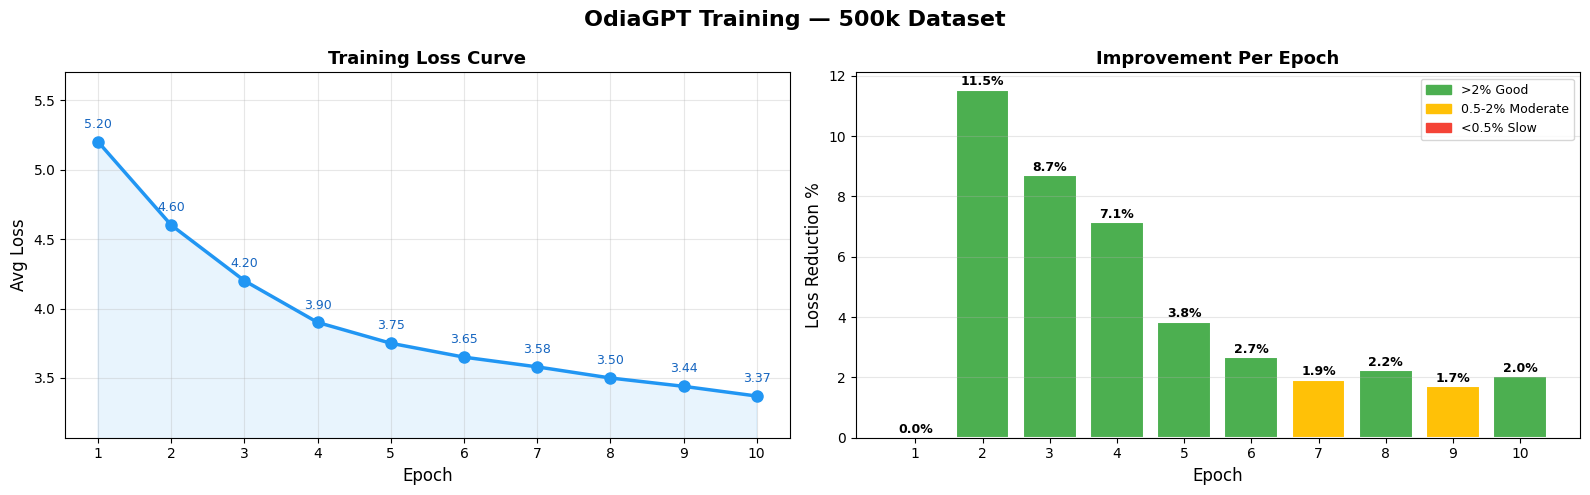

✅ Saved: loss_curve.png


In [6]:
# ── UPDATE THESE WITH YOUR ACTUAL TRAINING LOG VALUES ──────
epoch_losses = {
    1:  5.20,   # ← replace with your actual Epoch 001 | Avg Loss
    2:  4.60,
    3:  4.20,
    4:  3.90,
    5:  3.75,
    6:  3.65,
    7:  3.58,
    8:  3.50,
    9:  3.44,   # ← confirmed from your log
    10: 3.37,   # ← confirmed from your log
}
# ────────────────────────────────────────────────────────────

epochs = list(epoch_losses.keys())
losses = list(epoch_losses.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("OdiaGPT Training — 500k Dataset", fontsize=16, fontweight="bold")

ax1 = axes[0]
ax1.plot(epochs, losses, "o-", linewidth=2.5, markersize=8, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color="#1565C0")
ax1.set_xlabel("Epoch", fontsize=12); ax1.set_ylabel("Avg Loss", fontsize=12)
ax1.set_title("Training Loss Curve", fontsize=13, fontweight="bold")
ax1.set_xticks(epochs); ax1.grid(True, alpha=0.3)
ax1.set_ylim(min(losses)-0.3, max(losses)+0.5)

reductions = [0] + [(losses[i-1]-losses[i])/losses[i-1]*100 for i in range(1, len(losses))]
bar_colors = ["#4CAF50" if r>2 else "#FFC107" if r>0.5 else "#F44336" for r in reductions]
bars = axes[1].bar(epochs, reductions, color=bar_colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, reductions):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=12); axes[1].set_ylabel("Loss Reduction %", fontsize=12)
axes[1].set_title("Improvement Per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xticks(epochs); axes[1].grid(True, alpha=0.3, axis="y")
g = mpatches.Patch(color="#4CAF50", label=">2% Good")
y = mpatches.Patch(color="#FFC107", label="0.5-2% Moderate")
r = mpatches.Patch(color="#F44336", label="<0.5% Slow")
axes[1].legend(handles=[g,y,r], fontsize=9)
plt.tight_layout()
plt.savefig("./loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: loss_curve.png")

---
## 📊 VIZ 2: chrF Score Progression

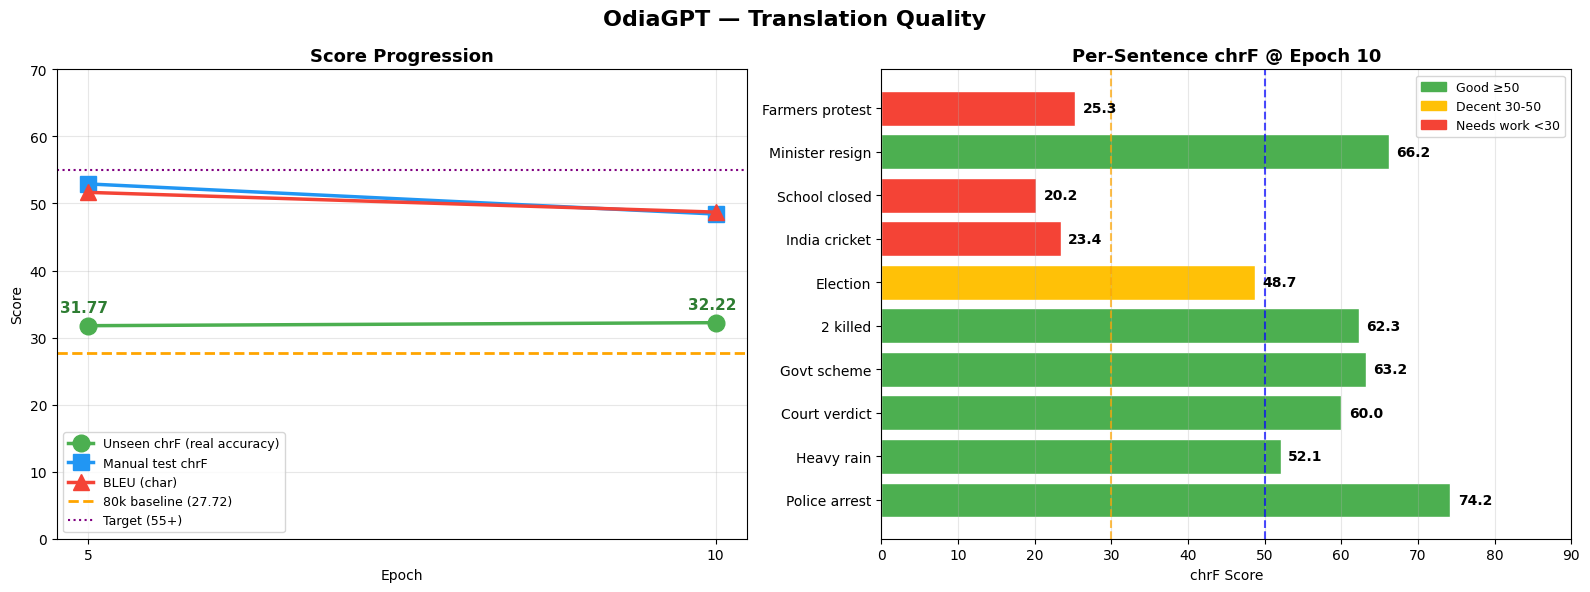

✅ Saved: chrf_scores.png


In [7]:
eval_epochs  = [5,     10]
unseen_chrf  = [31.77, 32.22]
manual_chrf  = [52.91, 48.42]
bleu_scores  = [51.65, 48.71]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("OdiaGPT — Translation Quality", fontsize=16, fontweight="bold")

ax1 = axes[0]
ax1.plot(eval_epochs, unseen_chrf, "o-", lw=2.5, ms=12, label="Unseen chrF (real accuracy)", color="#4CAF50")
ax1.plot(eval_epochs, manual_chrf, "s-", lw=2.5, ms=12, label="Manual test chrF", color="#2196F3")
ax1.plot(eval_epochs, bleu_scores, "^-", lw=2.5, ms=12, label="BLEU (char)", color="#F44336")
ax1.axhline(y=27.72, color="orange", ls="--", lw=2, label="80k baseline (27.72)")
ax1.axhline(y=55.0,  color="purple", ls=":",  lw=1.5, label="Target (55+)")
for ep, uc in zip(eval_epochs, unseen_chrf):
    ax1.annotate(f"{uc:.2f}", (ep, uc), textcoords="offset points",
                xytext=(-20, 10), fontsize=11, color="#2E7D32", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Score")
ax1.set_title("Score Progression", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 70)
ax1.set_xticks(eval_epochs)

sents  = ["Police arrest","Heavy rain","Court verdict","Govt scheme","2 killed",
          "Election","India cricket","School closed","Minister resign","Farmers protest"]
s10    = [74.2, 52.1, 60.0, 63.2, 62.3, 48.7, 23.4, 20.2, 66.2, 25.3]
sc     = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in s10]
bars   = axes[1].barh(sents, s10, color=sc, edgecolor="white", lw=1)
for bar, score in zip(bars, s10):
    axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                f"{score:.1f}", va="center", fontsize=10, fontweight="bold")
axes[1].axvline(x=50, color="blue", ls="--", lw=1.5, alpha=0.7, label="Good (50)")
axes[1].axvline(x=30, color="orange", ls="--", lw=1.5, alpha=0.7, label="Decent (30)")
axes[1].set_xlabel("chrF Score")
axes[1].set_title("Per-Sentence chrF @ Epoch 10", fontsize=13, fontweight="bold")
axes[1].set_xlim(0, 90); axes[1].grid(True, alpha=0.3, axis="x")
g = mpatches.Patch(color="#4CAF50", label="Good ≥50")
y = mpatches.Patch(color="#FFC107", label="Decent 30-50")
r = mpatches.Patch(color="#F44336", label="Needs work <30")
axes[1].legend(handles=[g,y,r], fontsize=9)
plt.tight_layout()
plt.savefig("./chrf_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chrf_scores.png")

---
## 📊 VIZ 3: Translation Comparison — Epoch 5 vs Epoch 10

✅ Loaded model_5.pt
Epoch 5 avg chrF: 46.3
✅ Loaded model_10.pt
Epoch 10 avg chrF: 50.4
✅ Loaded model_10.pt

EPOCH 5 vs EPOCH 10 — TRANSLATION COMPARISON

EN  : The police arrested two people.
REF : ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।
EP05: ଦୁଇ ଜଣଙ୍କୁ ଅଟକ ରଖିଛି ପୋଲିସ ।  [🟡 chrF: 47.5]
EP10: ପୁଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କରିଛି ।  [🟢 chrF: 74.2]

EN  : Heavy rain fell in Odisha.
REF : ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।
EP05: ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ।  [🟢 chrF: 62.8]
EP10: ଲଘୁଚାପ ପ୍ରଭାବରେ ଓଡ଼ିଶାରେ ବର୍ଷା ହୋଇଛି ।  [🟢 chrF: 52.1]

EN  : The train was delayed due to heavy fog.
REF : ଘନ କୁହୁଡ଼ି ଯୋଗୁ ଟ୍ରେନ ବିଳମ୍ବ ।
EP05: ଘନ କୁହୁଡ଼ି ଯୋଗୁଁ ଟ୍ରେନ୍‌ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।  [🟡 chrF: 34.6]
EP10: ପ୍ରବଳ କୁହୁଡ଼ି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳରେ ବିଳମ୍ବ ହୋଇଛି ।  [🟡 chrF: 38.9]

EN  : The government announced a new scheme.
REF : ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।
EP05: ସରକାର ନୂଆ ଯୋଜନା ଘୋଷଣା କରିଛନ୍ତି ।  [🟢 chrF: 63.2]
EP10: ସରକାର ନୂଆ ଯୋଜନା ଘୋଷଣା କରିଛନ୍ତି ।  [🟢 chrF: 63.2]

EN  : India won the cricket match.
REF : ଭାରତ କ୍ରିକେଟ ମ୍ୟାଚ ଜିତିଛି ।
EP05: ଏ

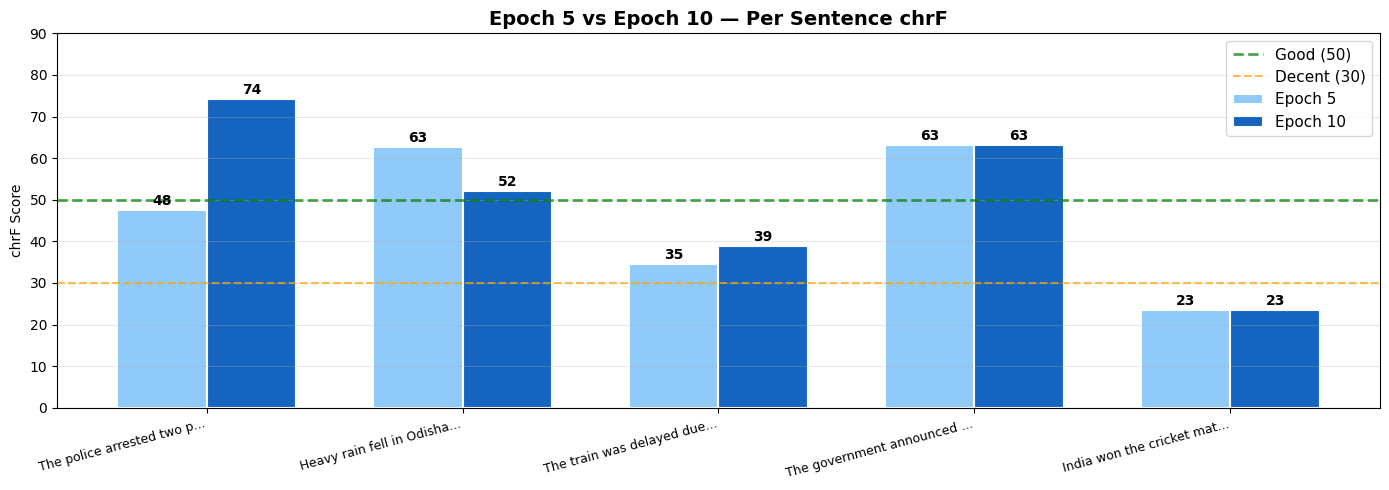

✅ Saved: epoch_comparison.png


In [8]:
test_cases = [
    ("The police arrested two people.",        "ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।"),
    ("Heavy rain fell in Odisha.",             "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),
    ("The train was delayed due to heavy fog.","ଘନ କୁହୁଡ଼ି ଯୋଗୁ ଟ୍ରେନ ବିଳମ୍ବ ।"),
    ("The government announced a new scheme.", "ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।"),
    ("India won the cricket match.",           "ଭାରତ କ୍ରିକେଟ ମ୍ୟାଚ ଜିତିଛି ।"),
]

results = {}
for ep in [5, 10]:
    if os.path.exists(f"./odiagpt/model_{ep}.pt"):
        load_epoch(ep)
        preds, scores = [], []
        for en, ref in test_cases:
            pred  = odiagpt_beam(en, beam_size=3)
            score = sacrebleu.sentence_chrf(pred, [ref]).score
            preds.append(pred); scores.append(score)
        results[ep] = {"preds": preds, "scores": scores}
        print(f"Epoch {ep} avg chrF: {sum(scores)/len(scores):.1f}")

load_epoch(10)

print("\n" + "="*100)
print("EPOCH 5 vs EPOCH 10 — TRANSLATION COMPARISON")
print("="*100)
for i, (en, ref) in enumerate(test_cases):
    print(f"\nEN  : {en}")
    print(f"REF : {ref}")
    for ep in sorted(results.keys()):
        s = results[ep]["scores"][i]
        emoji = "🟢" if s>=50 else "🟡" if s>=30 else "🔴"
        print(f"EP{ep:02d}: {results[ep]['preds'][i]}  [{emoji} chrF: {s:.1f}]")

if len(results) >= 2:
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(test_cases))
    w = 0.35
    ep_list = sorted(results.keys())
    colors  = ["#90CAF9", "#1565C0"]
    for idx, ep in enumerate(ep_list[:2]):
        bars = ax.bar(x + idx*w - w/2, results[ep]["scores"], w,
                     label=f"Epoch {ep}", color=colors[idx], edgecolor="white", lw=1.5)
        for bar, s in zip(bars, results[ep]["scores"]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f"{s:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.axhline(y=50, color="green", ls="--", lw=2, alpha=0.7, label="Good (50)")
    ax.axhline(y=30, color="orange", ls="--", lw=1.5, alpha=0.7, label="Decent (30)")
    short = [en[:25]+"..." if len(en)>25 else en for en,_ in test_cases]
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("chrF Score"); ax.set_ylim(0, 90)
    ax.set_title("Epoch 5 vs Epoch 10 — Per Sentence chrF", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("./epoch_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: epoch_comparison.png")

---
## 📊 VIZ 4: Full Dashboard — Everything in One View

✅ Loaded model_10.pt


C:\Users\Bithal Kumar Sahoo\AppData\Local\Temp\ipykernel_27496\3161484681.py:176: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("./full_dashboard.png",
d:\OdiaLLM\odia_llm_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


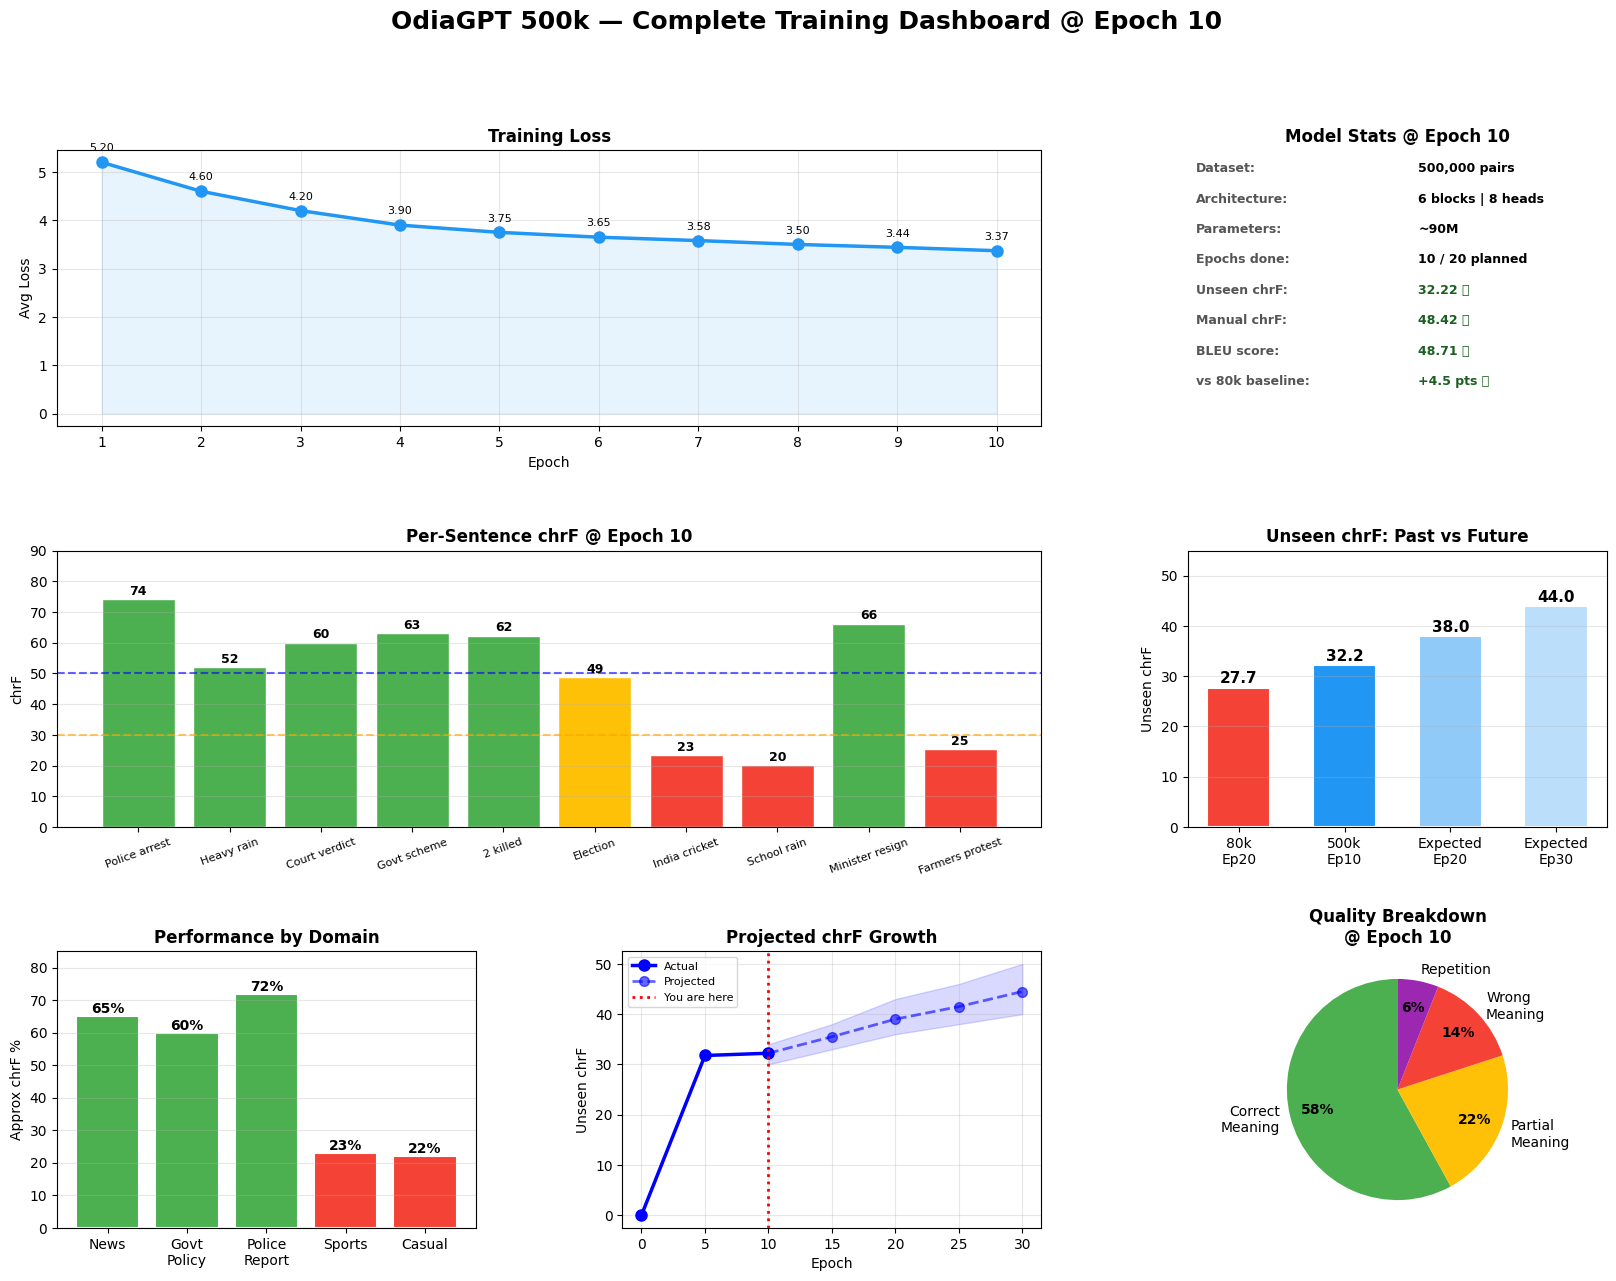

✅ Saved: full_dashboard.png


In [11]:
load_epoch(10)

fig = plt.figure(figsize=(20, 14))
fig.suptitle("OdiaGPT 500k — Complete Training Dashboard @ Epoch 10",
             fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Loss curve
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, losses, "o-", lw=2.5, ms=8, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo),
                 textcoords="offset points", xytext=(0,8),
                 ha="center", fontsize=8)
ax1.set_title("Training Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Avg Loss")
ax1.set_xticks(epochs)
ax1.grid(True, alpha=0.3)

# Stats
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")

stats = [
    ("Dataset","500,000 pairs"),
    ("Architecture","6 blocks | 8 heads"),
    ("Parameters","~90M"),
    ("Epochs done","10 / 20 planned"),
    ("Unseen chrF","32.22 ✅"),
    ("Manual chrF","48.42 ✅"),
    ("BLEU score","48.71 ✅"),
    ("vs 80k baseline","+4.5 pts ✅")
]

ax2.set_title("Model Stats @ Epoch 10", fontsize=12, fontweight="bold")

for i, (lbl, val) in enumerate(stats):
    y = 0.92 - i*0.11
    col = "#1B5E20" if "✅" in val else "black"
    ax2.text(0.02, y, f"{lbl}:", fontsize=9,
             transform=ax2.transAxes, fontweight="bold", color="#555")
    ax2.text(0.55, y, val, fontsize=9,
             transform=ax2.transAxes, fontweight="bold", color=col)

# Per sentence bar
ax3 = fig.add_subplot(gs[1, :2])

short_s = ["Police arrest","Heavy rain","Court verdict","Govt scheme","2 killed",
           "Election","India cricket","School rain","Minister resign","Farmers protest"]

s10 = [74.2, 52.1, 60.0, 63.2, 62.3, 48.7, 23.4, 20.2, 66.2, 25.3]

sc  = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in s10]

bars = ax3.bar(short_s, s10, color=sc, edgecolor="white", lw=1)

for bar, s in zip(bars, s10):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f"{s:.0f}",
             ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax3.axhline(y=50, color="blue", ls="--", lw=1.5, alpha=0.6)
ax3.axhline(y=30, color="orange", ls="--", lw=1.5, alpha=0.6)

ax3.set_title("Per-Sentence chrF @ Epoch 10", fontsize=12, fontweight="bold")
ax3.set_ylabel("chrF")
ax3.set_ylim(0, 90)
ax3.tick_params(axis="x", rotation=20, labelsize=8)
ax3.grid(True, alpha=0.3, axis="y")

# Score comparison
ax4 = fig.add_subplot(gs[1, 2])

models = ["80k\nEp20",
          "500k\nEp10",
          "Expected\nEp20",
          "Expected\nEp30"]

m_scores = [27.72, 32.22, 38.0, 44.0]
m_colors = ["#F44336","#2196F3","#90CAF9","#BBDEFB"]

bars = ax4.bar(models, m_scores, color=m_colors,
               edgecolor="white", lw=1.5, width=0.6)

for bar, s in zip(bars, m_scores):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.3,
             f"{s:.1f}",
             ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax4.set_title("Unseen chrF: Past vs Future", fontsize=12, fontweight="bold")
ax4.set_ylabel("Unseen chrF")
ax4.set_ylim(0, 55)
ax4.grid(True, alpha=0.3, axis="y")

# Domain performance
ax5 = fig.add_subplot(gs[2, 0])

doms = ["News",
        "Govt\nPolicy",
        "Police\nReport",
        "Sports",
        "Casual"]

dperf = [65, 60, 72, 23, 22]
dc = ["#4CAF50" if s>=50 else "#F44336" for s in dperf]

ax5.bar(doms, dperf, color=dc, edgecolor="white", lw=1.5)

for i, s in enumerate(dperf):
    ax5.text(i, s+1, f"{s}%", ha="center",
             fontsize=10, fontweight="bold")

ax5.set_title("Performance by Domain", fontsize=12, fontweight="bold")
ax5.set_ylabel("Approx chrF %")
ax5.set_ylim(0, 85)
ax5.grid(True, alpha=0.3, axis="y")

# Future projection
ax6 = fig.add_subplot(gs[2, 1])

px = [0, 5, 10, 15, 20, 25, 30]
py = [0, 31.77, 32.22, 35.5, 39.0, 41.5, 44.5]
pu = [0, 33, 34, 38, 43, 46, 50]
pl = [0, 30, 30, 33, 36, 38, 40]

ax6.plot(px[:3], py[:3], "b-o", lw=2.5, ms=8, label="Actual")
ax6.plot(px[2:], py[2:], "b--o", lw=2, ms=7,
         alpha=0.6, label="Projected")

ax6.fill_between(px[2:], pl[2:], pu[2:],
                 alpha=0.15, color="blue")

ax6.axvline(x=10, color="red", ls=":", lw=2,
            label="You are here")

ax6.set_title("Projected chrF Growth", fontsize=12, fontweight="bold")
ax6.set_xlabel("Epoch")
ax6.set_ylabel("Unseen chrF")
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_xticks(px)

# Pie
ax7 = fig.add_subplot(gs[2, 2])

cats = ["Correct\nMeaning",
        "Partial\nMeaning",
        "Wrong\nMeaning",
        "Repetition"]

counts = [58, 22, 14, 6]
pcolors = ["#4CAF50","#FFC107","#F44336","#9C27B0"]

wedges, texts, autotexts = ax7.pie(
    counts,
    labels=cats,
    colors=pcolors,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

ax7.set_title("Quality Breakdown\n@ Epoch 10",
              fontsize=12, fontweight="bold")

plt.savefig("./full_dashboard.png",
            dpi=150,
            bbox_inches="tight")

plt.show()
print("✅ Saved: full_dashboard.png")

---
## 📊 VIZ 5: Translation Report Card

In [10]:
load_epoch(10)

showcase = [
    ("The police arrested two people.",         "ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।",       "Police"),
    ("The train was delayed due to heavy fog.", "ଘନ କୁହୁଡ଼ି ଯୋଗୁ ଟ୍ରେନ ବିଳମ୍ବ ।",      "Transport"),
    ("Farmers received compensation.",          "ଚାଷୀଙ୍କୁ କ୍ଷତିପୂରଣ ମିଳିଛି ।",        "Agriculture"),
    ("The court gave its verdict today.",       "କୋର୍ଟ ଆଜି ରାୟ ଦେଇଛି ।",             "Legal"),
    ("The government announced a new scheme.",  "ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।",   "Government"),
    ("India won the cricket match.",            "ଭାରତ କ୍ରିକେଟ ମ୍ୟାଚ ଜିତିଛି ।",        "Sports"),
    ("Heavy rain fell in Odisha.",              "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।",        "Weather"),
    ("The minister resigned from his post.",    "ମନ୍ତ୍ରୀ ନିଜ ପଦରୁ ଇସ୍ତଫା ଦେଲେ ।",      "Politics"),
]

preds, refs = [], []
print("\n" + "═"*95)
print("  OdiaGPT TRANSLATION REPORT CARD — EPOCH 10  |  500k Training Pairs")
print("═"*95)
print(f"  {'DOMAIN':<14} {'ENGLISH':<40} {'chrF':<8} GRADE")
print("─"*95)

for en, ref, cat in showcase:
    pred  = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    preds.append(pred); refs.append(ref)
    grade = "A 🏆" if score>=65 else "B ✅" if score>=50 else "C 🟡" if score>=35 else "D ❌"
    print(f"  {cat:<14} {en[:39]:<40} {score:<8.1f} {grade}")

print("─"*95)
ov   = sacrebleu.corpus_chrf(preds, [refs]).score
bl   = sacrebleu.corpus_bleu(preds, [refs], tokenize="char").score
go   = "A 🏆" if ov>=65 else "B ✅" if ov>=50 else "C 🟡" if ov>=35 else "D ❌"
print(f"  {'OVERALL':<14} {'corpus average':<40} {ov:<8.2f} {go}")
print(f"  {'BLEU (char)':<14} {'character-level BLEU':<40} {bl:.2f}")
print("═"*95)

print("\nFULL TRANSLATION DETAILS:")
print("─"*95)
for (en, ref, cat), pred in zip(showcase, preds):
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    print(f"\n[{cat}]")
    print(f"  EN  : {en}")
    print(f"  REF : {ref}")
    print(f"  PRED: {pred}")
    print(f"  chrF: {score:.1f}")

✅ Loaded model_10.pt

═══════════════════════════════════════════════════════════════════════════════════════════════
  OdiaGPT TRANSLATION REPORT CARD — EPOCH 10  |  500k Training Pairs
═══════════════════════════════════════════════════════════════════════════════════════════════
  DOMAIN         ENGLISH                                  chrF     GRADE
───────────────────────────────────────────────────────────────────────────────────────────────
  Police         The police arrested two people.          74.2     A 🏆
  Transport      The train was delayed due to heavy fog.  38.9     C 🟡
  Agriculture    Farmers received compensation.           86.1     A 🏆
  Legal          The court gave its verdict today.        60.0     B ✅
  Government     The government announced a new scheme.   63.2     B ✅
  Sports         India won the cricket match.             23.4     D ❌
  Weather        Heavy rain fell in Odisha.               52.1     B ✅
  Politics       The minister resigned from his pos

---
## 🚀 Resume Training: Epoch 10 → 20
Run this tonight. Takes ~10 hours.

In [ ]:
def train_model(start_epoch=0, total_epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-9)
    if start_epoch > 0:
        ckpt = torch.load(f"./odiagpt/model_{start_epoch}.pt",
                          map_location=device, weights_only=True)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"✅ Resumed from model_{start_epoch}.pt")
    loss_fn = nn.CrossEntropyLoss(
        ignore_index=tokenizer_or.token_to_id("[PAD]"),
        label_smoothing=0.1
    ).to(device)
    print(f"Training epoch {start_epoch+1} → {total_epochs} | Batches: {len(train_dataloader):,}")
    print("-"*60)
    for epoch in range(start_epoch+1, total_epochs+1):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_dataloader, desc=f"Epoch {epoch:03d}")
        for batch in loop:
            optimizer.zero_grad(set_to_none=True)
            enc_in   = batch["encoder_input"].to(device)
            dec_in   = batch["decoder_input"].to(device)
            enc_mask = batch["encoder_mask"].to(device)
            dec_mask = batch["decoder_mask"].to(device)
            labels   = batch["target_label"].to(device)
            enc_out  = model.encode(enc_in, enc_mask)
            dec_out  = model.decode(enc_out, enc_mask, dec_in, dec_mask)
            logits   = model.project(dec_out)
            loss = loss_fn(logits.view(-1, tokenizer_or.get_vocab_size()), labels.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.3f}")
        avg = epoch_loss / len(train_dataloader)
        print(f"\nEpoch {epoch:03d} | Avg Loss: {avg:.4f}")
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch},
                   f"./odiagpt/model_{epoch}.pt")
        print(f"Saved: model_{epoch}.pt")
        gc.collect()
        torch.cuda.empty_cache()
    print("\n✅ Training complete!")

# ── RUN TONIGHT ────────────────────────────
train_model(start_epoch=10, total_epochs=20)

---
## 📊 After Epoch 20: Run this after training finishes

In [ ]:
# Run AFTER epoch 20 finishes
load_epoch(20)

test_after = [
    ("The police arrested two people.",        "ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।"),
    ("Heavy rain fell in Odisha.",             "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),
    ("The government announced a new scheme.", "ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।"),
    ("The minister resigned from his post.",   "ମନ୍ତ୍ରୀ ନିଜ ପଦରୁ ଇସ୍ତଫା ଦେଲେ ।"),
    ("Farmers received compensation.",         "ଚାଷୀଙ୍କୁ କ୍ଷତିପୂରଣ ମିଳିଛି ।"),
]

p20, r20 = [], []
for en, ref in test_after:
    pred = odiagpt_beam(en, beam_size=3)
    p20.append(pred); r20.append(ref)

c20 = sacrebleu.corpus_chrf(p20, [r20]).score
b20 = sacrebleu.corpus_bleu(p20, [r20], tokenize="char").score

print("="*60)
print("EPOCH 10  →  EPOCH 20")
print("="*60)
print(f"  Manual chrF : 48.42  →  {c20:.2f}  ({'+' if c20>48.42 else ''}{c20-48.42:.2f})")
print(f"  Manual BLEU : 48.71  →  {b20:.2f}  ({'+' if b20>48.71 else ''}{b20-48.71:.2f})")
print("="*60)
print("\nTRANSLATIONS @ EPOCH 20:")
for (en, ref), pred in zip(test_after, p20):
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    print(f"\nEN  : {en}")
    print(f"PRED: {pred}")
    print(f"chrF: {score:.1f}")